# Imports

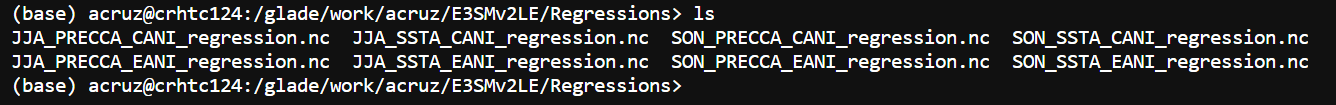

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import colormaps as cmaps

# map def

In [3]:
def reg_map(ds_to_plt, comparison, bounds=[20, -180, 30, -30], name='figure',
           color=cmaps.posneg_1, lcolor=['magenta', 'cyan'],
           lev=np.arange(-1.5, 1.5, 0.15)):

    fig, ax = plt.subplots(1, 1,
                           subplot_kw={'projection': ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)
    ccomp, ccomp_lon = cutil.add_cyclic_point(comparison, comparison.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2]+1, 10)
    lon_ticks = np.arange(bounds[1], bounds[0], 60)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

# local function because it modifies local objects
    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0,
                              0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())
    re_contour = ax.contourf(ccomp_lon, comparison.lat, ccomp,
                             levels=lev,
                             # levels=40,
                             transform=ccrs.PlateCarree(), cmap=color,
                             extend='both')
    
    mod_contour = ax.contourf(clon, ds_to_plt.lat, cdat,
                              transform=ccrs.PlateCarree(),
                              linestyles='-',
                              hatches=['...'],
                              levels=[-0.1, 0, 0.1],
                              colors=lcolor,
                              alpha=0.1,
                              extend='both')

    fig.canvas.mpl_connect('resize_event', resize_colobar)
    ax.add_feature(cf.LAND)
    ax.coastlines()
    plt.colorbar(re_contour, cax=cbar_ax)
    resize_colobar(None)
    plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()

In [4]:
def reg_map_single(ds_to_plt, comparison, bounds=[20, -180, 30, -30], name='figure',
           color=cmaps.posneg_1, lcolor=['magenta', 'cyan'],
           lev=np.arange(-1.5, 1.5, 0.15)):

    fig, ax = plt.subplots(1, 1,
                           subplot_kw={'projection': ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)
    ccomp, ccomp_lon = cutil.add_cyclic_point(comparison, comparison.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2]+1, 15)
    lon_ticks = np.arange(bounds[1], bounds[0], 60)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

# local function because it modifies local objects
    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0,
                              0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())
    re_contour = ax.contourf(ccomp_lon, comparison.lat, ccomp,
                             levels=lev,
                             # levels=40,
                             transform=ccrs.PlateCarree(), cmap=color,
                             extend='both')
    
    mod_contour = ax.contourf(clon, ds_to_plt.lat, cdat,
                              transform=ccrs.PlateCarree(),
                              linestyles='-',
                              hatches=['..',''],
                              levels=[0, 0.05],
                              colors='None',#lcolor,
                              alpha=0.1,
                              )

    fig.canvas.mpl_connect('resize_event', resize_colobar)
    ax.add_feature(cf.LAND)
    ax.coastlines()
    plt.colorbar(re_contour, cax=cbar_ax)
    resize_colobar(None)
    plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()

# Data select

In [5]:
JJASSTA_CANI_r = xr.open_dataset('/glade/work/acruz/E3SMv2LE/Regressions/JJA_SSTA_CANI_regression.nc')
JJASSTA_EANI_r = xr.open_dataset('/glade/work/acruz/E3SMv2LE/Regressions/JJA_SSTA_EANI_regression.nc')
SONSSTA_CANI_r = xr.open_dataset('/glade/work/acruz/E3SMv2LE/Regressions/SON_SSTA_CANI_regression.nc')
SONSSTA_EANI_r = xr.open_dataset('/glade/work/acruz/E3SMv2LE/Regressions/SON_SSTA_EANI_regression.nc')

JJAPRECCA_CANI_r = xr.open_dataset('/glade/work/acruz/E3SMv2LE/Regressions/JJA_PRECCA_CANI_regression.nc')
JJAPRECCA_EANI_r = xr.open_dataset('/glade/work/acruz/E3SMv2LE/Regressions/JJA_PRECCA_EANI_regression.nc')
SONPRECCA_CANI_r = xr.open_dataset('/glade/work/acruz/E3SMv2LE/Regressions/SON_PRECCA_CANI_regression.nc')
SONPRECCA_EANI_r = xr.open_dataset('/glade/work/acruz/E3SMv2LE/Regressions/SON_PRECCA_EANI_regression.nc')
# reanalysisC/EANI_SEASONvar_regression
rCANI_JJAprecip_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/CANI_precip_JJA.nc')
rCANI_SONprecip_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/CANI_precip_SON.nc')
rEANI_JJAprecip_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/EANI_precip_JJA.nc')
rEANI_SONprecip_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/EANI_precip_SON.nc')

rCANI_JJA_SSTA_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/CANI_SSTA_JJA.nc')
rCANI_SON_SSTA_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/CANI_SSTA_SON.nc')
rEANI_JJA_SSTA_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/EANI_SSTA_JJA.nc')
rEANI_SON_SSTA_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/EANI_SSTA_SON.nc')

In [6]:
new_dims = {'longitude': 'lon', 'latitude': 'lat'}

rCANI_JJA_SSTA_r = rCANI_JJA_SSTA_r.rename(new_dims)
rCANI_SON_SSTA_r = rCANI_SON_SSTA_r.rename(new_dims)
rEANI_JJA_SSTA_r = rEANI_JJA_SSTA_r.rename(new_dims)
rEANI_SON_SSTA_r = rEANI_SON_SSTA_r.rename(new_dims)

In [8]:
rCANI_JJA_SSTA_r = rCANI_JJA_SSTA_r.sortby(rCANI_JJA_SSTA_r.lat)
rCANI_SON_SSTA_r = rCANI_SON_SSTA_r.sortby(rCANI_SON_SSTA_r.lat)
rEANI_JJA_SSTA_r = rEANI_JJA_SSTA_r.sortby(rCANI_JJA_SSTA_r.lat)
rEANI_SON_SSTA_r = rEANI_SON_SSTA_r.sortby(rEANI_SON_SSTA_r.lat)

# Select only significant values in reanalysis

In [9]:
rCANI_JJAprecip_slope_sig = rCANI_JJAprecip_r['slope'].where(rCANI_JJAprecip_r['pvalue'] <= 0.05)
rCANI_SONprecip_slope_sig = rCANI_SONprecip_r['slope'].where(rCANI_SONprecip_r['pvalue'] <= 0.05)
rEANI_JJAprecip_slope_sig = rEANI_JJAprecip_r['slope'].where(rEANI_JJAprecip_r['pvalue'] <= 0.05)
rEANI_SONprecip_slope_sig = rEANI_SONprecip_r['slope'].where(rEANI_SONprecip_r['pvalue'] <= 0.05)

rCANI_JJA_SSTA_slope_sig = rCANI_JJA_SSTA_r['slope'].where(rCANI_JJA_SSTA_r['pvalue'] <= 0.05)
rCANI_SON_SSTA_slope_sig = rCANI_SON_SSTA_r['slope'].where(rCANI_SON_SSTA_r['pvalue'] <= 0.05)
rEANI_JJA_SSTA_slope_sig = rEANI_JJA_SSTA_r['slope'].where(rEANI_JJA_SSTA_r['pvalue'] <= 0.05)
rEANI_SON_SSTA_slope_sig = rEANI_SON_SSTA_r['slope'].where(rEANI_SON_SSTA_r['pvalue'] <= 0.05)

# Ensemble means

In [28]:
ens_jja_SSTAvEANI = JJASSTA_EANI_r.mean(dim='member')
ens_jja_SSTAvCANI = JJASSTA_CANI_r.mean(dim='member')
ens_son_SSTAvEANI = SONSSTA_EANI_r.mean(dim='member')
ens_son_SSTAvCANI = SONSSTA_CANI_r.mean(dim='member')

ens_jja_PRECCAvCANI = JJAPRECCA_CANI_r.mean(dim='member')
ens_jja_PRECCAvEANI = JJAPRECCA_EANI_r.mean(dim='member')
ens_son_PRECCAvCANI = SONPRECCA_CANI_r.mean(dim='member')
ens_son_PRECCAvEANI = SONPRECCA_EANI_r.mean(dim='member')

In [11]:
ens_jja_SSTAvEANI_sig_slope = ens_jja_SSTAvEANI['slope'].where(ens_jja_SSTAvEANI['pvalue'] <= 0.05)
ens_jja_SSTAvCANI_sig_slope = ens_jja_SSTAvCANI['slope'].where(ens_jja_SSTAvCANI['pvalue'] <= 0.05)
ens_son_SSTAvEANI_sig_slope = ens_son_SSTAvEANI['slope'].where(ens_son_SSTAvEANI['pvalue'] <= 0.05)
ens_son_SSTAvCANI_sig_slope = ens_son_SSTAvCANI['slope'].where(ens_son_SSTAvCANI['pvalue'] <= 0.05)

In [12]:
ens_jja_PRECCAvCANI_sig_slope = ens_jja_PRECCAvCANI['slope'].where(ens_jja_PRECCAvCANI['pvalue'] <= 0.05)
ens_jja_PRECCAvEANI_sig_slope = ens_jja_PRECCAvEANI['slope'].where(ens_jja_PRECCAvEANI['pvalue'] <= 0.05)
ens_son_PRECCAvEANI_sig_slope = ens_son_PRECCAvEANI['slope'].where(ens_son_PRECCAvEANI['pvalue'] <= 0.05)
ens_son_PRECCAvCANI_sig_slope = ens_son_PRECCAvCANI['slope'].where(ens_son_PRECCAvCANI['pvalue'] <= 0.05)

In [13]:
jja_PRECCAvEANI_sig_slope = JJAPRECCA_EANI_r['slope'].where(JJAPRECCA_EANI_r['pvalue'] <= 0.05)
jja_PRECCAvCANI_sig_slope = JJAPRECCA_CANI_r['slope'].where(JJAPRECCA_CANI_r['pvalue'] <= 0.05)
son_PRECCAvEANI_sig_slope = SONPRECCA_EANI_r['slope'].where(SONPRECCA_EANI_r['pvalue'] <= 0.05)
son_PRECCAvCANI_sig_slope = SONPRECCA_CANI_r['slope'].where(SONPRECCA_CANI_r['pvalue'] <= 0.05)

In [14]:
jja_SSTAvEANI_sig_slope = JJASSTA_EANI_r['slope'].where(JJASSTA_EANI_r['pvalue'] <= 0.05, 0)
jja_SSTAvCANI_sig_slope = JJASSTA_CANI_r['slope'].where(JJASSTA_CANI_r['pvalue'] <= 0.05, 0)
son_SSTAvEANI_sig_slope = SONSSTA_EANI_r['slope'].where(SONSSTA_EANI_r['pvalue'] <= 0.05, 0)
son_SSTAvCANI_sig_slope = SONSSTA_CANI_r['slope'].where(SONSSTA_CANI_r['pvalue'] <= 0.05, 0)

In [51]:
# This is the ensemble mean of significant slopes (masked before reduction)
ens_ss_jja_SSTAvEANI = jja_SSTAvEANI_sig_slope.mean(dim='member')
ens_ss_jja_SSTAvCANI = jja_SSTAvCANI_sig_slope.mean(dim='member')
ens_ss_son_SSTAvEANI = son_SSTAvEANI_sig_slope.mean(dim='member')
ens_ss_son_SSTAvCANI = son_SSTAvCANI_sig_slope.mean(dim='member')

ens_ss_jja_PRECCAvCANI = jja_PRECCAvCANI_sig_slope.mean(dim='member')
ens_ss_jja_PRECCAvEANI = jja_PRECCAvEANI_sig_slope.mean(dim='member')
ens_ss_son_PRECCAvCANI = son_PRECCAvCANI_sig_slope.mean(dim='member')
ens_ss_son_PRECCAvEANI = son_PRECCAvEANI_sig_slope.mean(dim='member')

# Plots

## SST

### Reanalysis

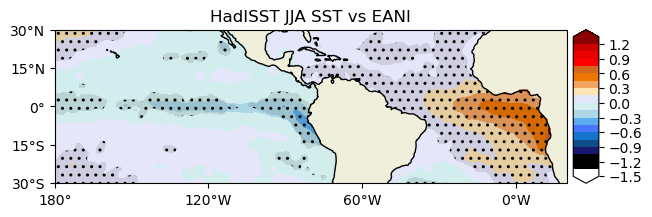

In [19]:
reg_map_single(rEANI_JJA_SSTA_r['pvalue'], rEANI_JJA_SSTA_r['slope'],
        name='HadISST JJA SSTA vs EANI')

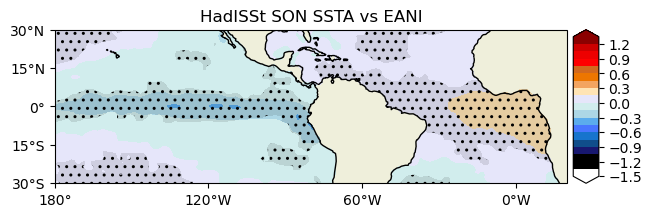

In [20]:
reg_map_single(rEANI_SON_SSTA_r['pvalue'], rEANI_SON_SSTA_r['slope'],
        name='HadISSt SON SSTA vs EANI')

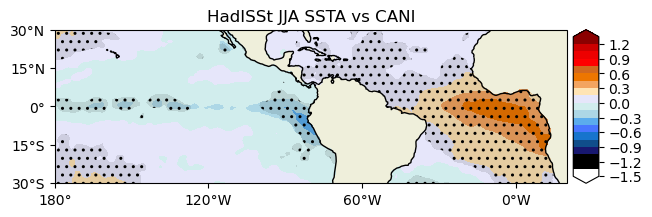

In [21]:
reg_map_single(rCANI_JJA_SSTA_r['pvalue'], rCANI_JJA_SSTA_r['slope'],
        name='HadISSt JJA SSTA vs CANI')

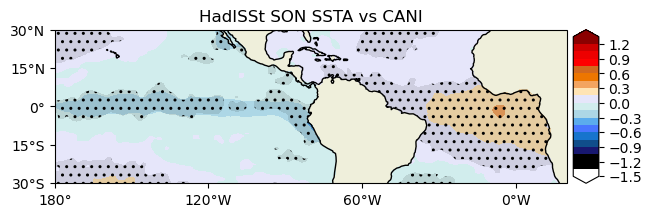

In [22]:
reg_map_single(rCANI_SON_SSTA_r['pvalue'], rCANI_SON_SSTA_r['slope'],
        name='HadISSt SON SSTA vs CANI')

### E3SMv2

In [25]:
ens_jja_SSTAvEANI

<xarray.DataArray 'slope' (lat: 192, lon: 288)> Size: 221kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8

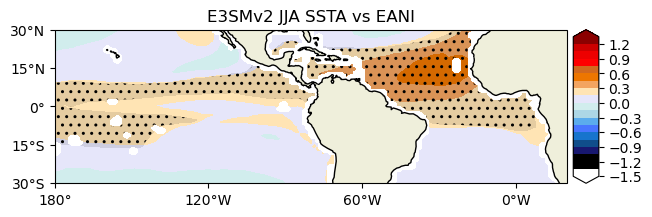

In [33]:
reg_map_single(ens_jja_SSTAvEANI['pvalue'], ens_jja_SSTAvEANI['slope'],
        name='E3SMv2 JJA SSTA vs EANI')

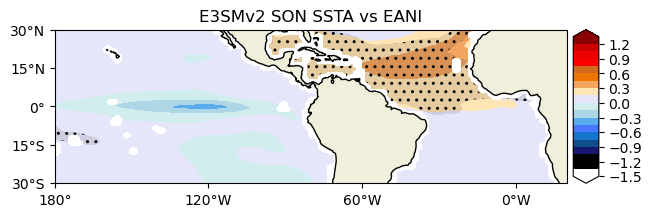

In [34]:
reg_map_single(ens_son_SSTAvEANI['pvalue'], ens_son_SSTAvEANI['slope'],
        name='E3SMv2 SON SSTA vs EANI')

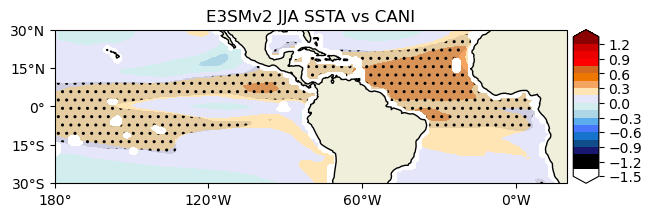

In [35]:
reg_map_single(ens_jja_SSTAvCANI['pvalue'], ens_jja_SSTAvCANI['slope'],
        name='E3SMv2 JJA SSTA vs CANI')

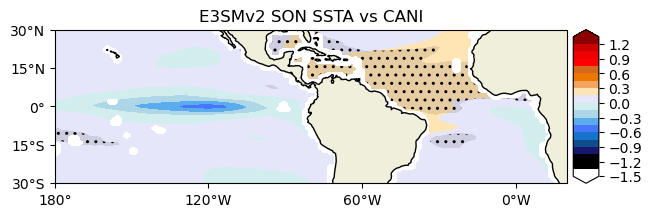

In [36]:
reg_map_single(ens_son_SSTAvCANI['pvalue'], ens_son_SSTAvCANI['slope'],
        name='E3SMv2 SON SSTA vs CANI')

## Precip

### Reanalysis

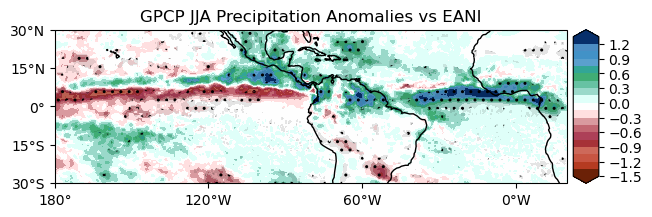

In [38]:
reg_map_single(rEANI_JJAprecip_r['pvalue'], rEANI_JJAprecip_r['slope'],
        name='GPCP JJA Precipitation Anomalies vs EANI',
        color=cmaps.precip4_diff_19lev)

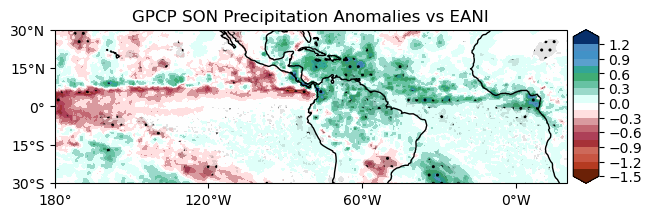

In [39]:
reg_map_single(rEANI_SONprecip_r['pvalue'], rEANI_SONprecip_r['slope'],
        name='GPCP SON Precipitation Anomalies vs EANI',
        color=cmaps.precip4_diff_19lev)

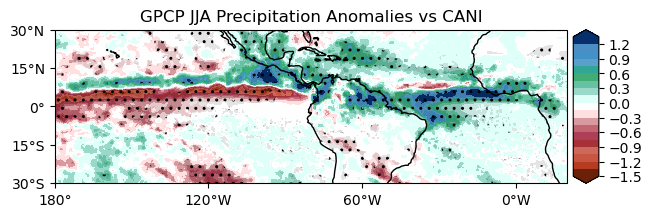

In [40]:
reg_map_single(rCANI_JJAprecip_r['pvalue'], rCANI_JJAprecip_r['slope'],
        name='GPCP JJA Precipitation Anomalies vs CANI',
        color=cmaps.precip4_diff_19lev)

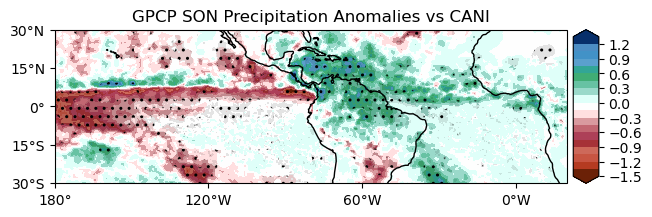

In [41]:
reg_map_single(rCANI_SONprecip_r['pvalue'], rCANI_SONprecip_r['slope'],
        name='GPCP SON Precipitation Anomalies vs CANI',
        color=cmaps.precip4_diff_19lev)

### E3SMv2

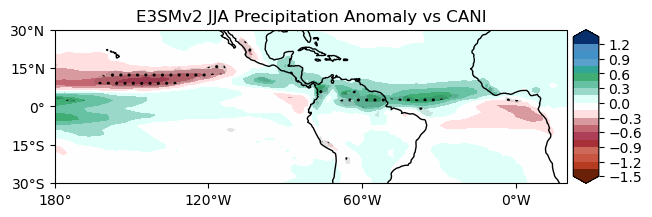

In [46]:
# conversion from m/s to mm/day
ens_jja_PRECTvCANI_con = ens_jja_PRECCAvCANI['slope'] * ( 1000 * (24*60*60))

reg_map_single(ens_jja_PRECCAvCANI['pvalue'], ens_jja_PRECTvCANI_con,
        name='E3SMv2 JJA Precipitation Anomaly vs CANI',
        color=cmaps.precip4_diff_19lev)

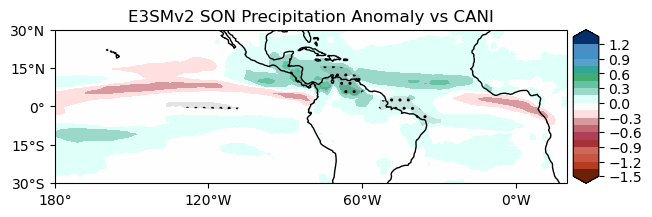

In [47]:
# conversion from m/s to mm/day
ens_son_PRECTvCANI_con = ens_son_PRECCAvCANI['slope'] * ( 1000 * (24*60*60))

reg_map_single(ens_son_PRECCAvCANI['pvalue'], ens_son_PRECTvCANI_con,
        name='E3SMv2 SON Precipitation Anomaly vs CANI',
        color=cmaps.precip4_diff_19lev)

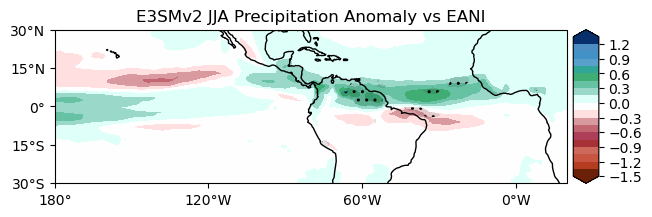

In [48]:
# conversion from m/s to mm/day
ens_jja_PRECTvEANI_con = ens_jja_PRECCAvEANI['slope'] * ( 1000 * (24*60*60))

reg_map_single(ens_jja_PRECCAvEANI['pvalue'], ens_jja_PRECTvEANI_con,
        name='E3SMv2 JJA Precipitation Anomaly vs EANI',
        color=cmaps.precip4_diff_19lev)

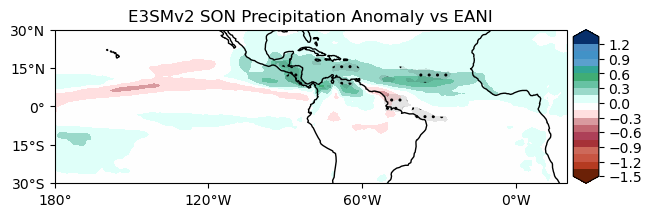

In [50]:
# conversion from m/s to mm/day
ens_son_PRECTvEANI_con = ens_son_PRECCAvEANI['slope'] * ( 1000 * (24*60*60))

reg_map_single(ens_son_PRECCAvEANI['pvalue'], ens_son_PRECTvEANI_con,
        name='E3SMv2 SON Precipitation Anomaly vs EANI',
        color=cmaps.precip4_diff_19lev)